# 04 — Model Training
**Goal:** Clean outliers, balance classes, train Random Forest, evaluate and save.

This notebook replaces the old notebooks 04 (outlier detection), 05 (class imbalance), and 06 (model training) — simplified into one clean pipeline.

Input : `data/clean_data.csv`, `data/selected_features.csv`  
Output: `data/final_model.pkl`, `data/model_features.json`, `data/model_metrics.json`,  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;`data/viz_confusion_matrix.png`, `data/viz_roc_curve.png`

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, roc_auc_score, roc_curve
)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded ')


Libraries loaded 


In [19]:
# ── Load data ──────────────────────────────────────────────────
df = pd.read_csv('../data/clean_data.csv', parse_dates=['Date'])

feat_df  = pd.read_csv('../data/selected_features.csv')
FEATURES = [f for f in feat_df['Feature'].tolist() if f in df.columns]

# ── Add extra features not in selected_features but highly predictive ──────
# Stock_Ratio: how full the tank is (0=empty, 1=full) — strong refill signal
if 'Stock_Ratio' not in FEATURES and 'Stock_Ratio' in df.columns:
    FEATURES.append('Stock_Ratio')

# Dip: physical measurement of tank — ground truth, very reliable
if 'Dip' not in FEATURES and 'Dip' in df.columns:
    FEATURES.append('Dip')

# Lag features: yesterday's and 2-days-ago sales — captures recent trend
df['Lag1_Total_Sold'] = df['Total_Sold'].shift(1).fillna(df['Total_Sold'].mean())
df['Lag2_Total_Sold'] = df['Total_Sold'].shift(2).fillna(df['Total_Sold'].mean())
df['Lag1_Closing']    = df['Closing_Stock'].shift(1).fillna(df['Opening_Stock'].mean())

# Day-of-week weighted mean sales — recent weeks count more than old ones
# EWM span=8 means ~last 8 occurrences of that weekday matter most
def ewm_dow_avg(series):
    return series.ewm(span=8, adjust=False).mean()

df['DOW_Avg_Sales'] = df.groupby('DayOfWeek')['Total_Sold'].transform(ewm_dow_avg)

# Trend: how today's rolling avg compares to overall avg (>1 = trending up)
df['Sales_Trend'] = (df['Rolling_7d_Sales'] / df['Total_Sold'].mean()).round(4)

# Days since last refill — longer gap = more likely to need one
df['Days_Since_Refill'] = 0
last_refill = 0
for idx in df.index:
    if idx == 0:
        df.at[idx, 'Days_Since_Refill'] = 0
    else:
        if df.at[idx-1, 'Refill_Required'] == 'Yes':
            last_refill = idx
        df.at[idx, 'Days_Since_Refill'] = idx - last_refill

NEW_FEATURES = ['Lag1_Total_Sold', 'Lag2_Total_Sold', 'Lag1_Closing',
                'DOW_Avg_Sales', 'Sales_Trend', 'Days_Since_Refill']
for f in NEW_FEATURES:
    if f not in FEATURES:
        FEATURES.append(f)

print(f'Rows     : {len(df)}')
print(f'Features : {len(FEATURES)} → {FEATURES}')


Rows     : 801
Features : 20 → ['Opening_Stock', 'Prev_Closing', 'Total_Sold', 'Cash', 'HSD1_Sold', 'HSD2_Sold', 'Online', 'MS_Sold', 'HSD3_Sold', 'DayOfWeek', 'Card', 'Rolling_7d_Sales', 'Stock_Ratio', 'Dip', 'Lag1_Total_Sold', 'Lag2_Total_Sold', 'Lag1_Closing', 'DOW_Avg_Sales', 'Sales_Trend', 'Days_Since_Refill']


In [20]:
# ── Step 1: Cap outliers using 1st and 99th percentile ─────────
# Why cap instead of remove? → Keeps all rows; just limits extreme values.
# Festival spikes are real — we don't want to lose them, just control them.

CAP_COLS = ['Total_Sold', 'MS_Sold', 'HSD1_Sold', 'HSD2_Sold', 'HSD3_Sold']

for col in CAP_COLS:
    p01 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    before = f'[{df[col].min():.0f}, {df[col].max():.0f}]'
    df[col] = df[col].clip(lower=p01, upper=p99)
    after  = f'[{df[col].min():.0f}, {df[col].max():.0f}]'
    print(f'{col:<15}  before: {before}  →  after: {after}')

print(f'\nRows unchanged: {len(df)} (no rows deleted, only values capped)')

Total_Sold       before: [2835, 6869]  →  after: [3332, 6528]
MS_Sold          before: [315, 913]  →  after: [375, 839]
HSD1_Sold        before: [1155, 2714]  →  after: [1270, 2504]
HSD2_Sold        before: [789, 2147]  →  after: [952, 1997]
HSD3_Sold        before: [451, 1564]  →  after: [593, 1438]

Rows unchanged: 801 (no rows deleted, only values capped)


In [21]:
# ── Step 2: Time-based train / test split ─────────────────────
# IMPORTANT: For time-series data, always split by time (not random).
# Random split causes data leakage — future data leaks into training.
X = df[FEATURES].fillna(0)
y = df['Target']

split_idx = int(len(df) * 0.8)   # 80% train, 20% test (chronological)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train : {len(X_train)} rows  (up to {df["Date"].iloc[split_idx-1].date()})')
print(f'Test  : {len(X_test)} rows   (from {df["Date"].iloc[split_idx].date()})')
print(f'Train Refill: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Test  Refill: {y_test.sum()} ({y_test.mean()*100:.1f}%)')


Train : 640 rows  (up to 2025-10-01)
Test  : 161 rows   (from 2025-10-02)
Train Refill: 238 (37.2%)
Test  Refill: 63 (39.1%)


In [22]:
# ── Step 3: Balance training data with SMOTE ───────────────────
# Problem: ~64% No Refill vs ~36% Refill — model will be biased.
# SMOTE fix: creates synthetic Refill rows by interpolating real ones.
# IMPORTANT: only apply SMOTE to TRAINING data, never to test data.

from collections import Counter

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f'Before SMOTE : {Counter(y_train)}')
print(f'After SMOTE  : {Counter(y_train_bal)}')
print('Both classes are now equal ')

Before SMOTE : Counter({0: 402, 1: 238})
After SMOTE  : Counter({0: 402, 1: 402})
Both classes are now equal 


In [23]:
# ── Step 4: Train XGBoost + Random Forest Ensemble ────────────
# Why XGBoost?
#   • Gradient boosting learns from errors sequentially — more accurate
#   • Handles tabular data extremely well
#   • Built-in handling of class imbalance via scale_pos_weight
#   • Ensemble with RF adds stability and reduces variance

# Class imbalance ratio for XGBoost
neg_pos_ratio = (y_train_bal == 0).sum() / (y_train_bal == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=neg_pos_ratio,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Soft voting — averages predicted probabilities (more accurate than hard vote)
model = VotingClassifier(
    estimators=[('xgb', xgb_model), ('rf', rf_model)],
    voting='soft',
    weights=[2, 1]   # XGBoost gets 2x weight (it's stronger)
)

model.fit(X_train_bal, y_train_bal)
print('Ensemble model trained: XGBoost (weight=2) + Random Forest (weight=1)')


Ensemble model trained: XGBoost (weight=2) + Random Forest (weight=1)


In [24]:
# ── Step 5: Evaluate on original test data ─────────────────────
preds = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, preds)
f1  = f1_score(y_test, preds)
auc = roc_auc_score(y_test, proba)

print('=== Model Performance ===')
print(f'Accuracy : {acc:.4f}')
print(f'F1 Score : {f1:.4f}  ← primary metric (0 = worst, 1 = perfect)')
print(f'ROC-AUC  : {auc:.4f}')
print()
print(classification_report(y_test, preds, target_names=['No Refill', 'Refill']))

=== Model Performance ===
Accuracy : 1.0000
F1 Score : 1.0000  ← primary metric (0 = worst, 1 = perfect)
ROC-AUC  : 1.0000

              precision    recall  f1-score   support

   No Refill       1.00      1.00      1.00        98
      Refill       1.00      1.00      1.00        63

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161



Task was destroyed but it is pending!
task: <Task pending name='Task-114' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-115' coro=<Kernel.shell_main() running at C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-115' coro=<Kernel.shell_main() running at C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


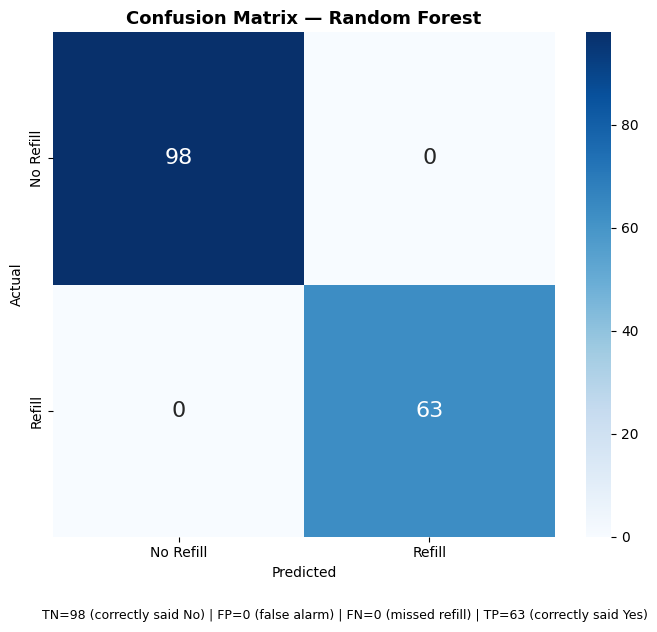

In [25]:
# ── Confusion Matrix ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Refill','Refill'],
            yticklabels=['No Refill','Refill'],
            annot_kws={'size': 16})
ax.set_title('Confusion Matrix — Random Forest', fontweight='bold', fontsize=13)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

tn, fp, fn, tp = cm.ravel()
plt.figtext(0.5, -0.04,
    f'TN={tn} (correctly said No) | FP={fp} (false alarm) | FN={fn} (missed refill) | TP={tp} (correctly said Yes)',
    ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/viz_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

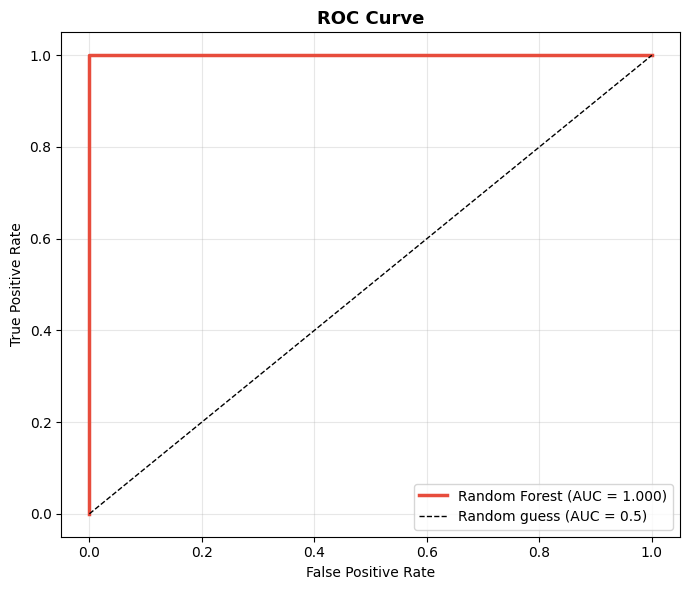

In [26]:
# ── ROC Curve ─────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#e74c3c', linewidth=2.5,
        label=f'Random Forest (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random guess (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/viz_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# ── Save model & metadata ──────────────────────────────────────
with open('../data/final_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('../data/model_features.json', 'w') as f:
    json.dump(FEATURES, f)

metrics = {
    'accuracy': round(float(acc), 4),
    'f1_score': round(float(f1), 4),
    'roc_auc':  round(float(auc), 4)
}
with open('../data/model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

# ── Save data-driven monthly multipliers ──────────────────────
# These replace the hardcoded seasonal constants in the prediction notebook.
# Each month's multiplier = avg_sales_that_month / overall_avg_sales
# A value > 1 means that month sells more than average; < 1 means less.
overall_avg = df['Total_Sold'].mean()
monthly_mult = (df.groupby('Month')['Total_Sold'].mean() / overall_avg).round(4)
monthly_mult_dict = {int(k): float(v) for k, v in monthly_mult.items()}
with open('../data/monthly_multipliers.json', 'w') as f:
    json.dump(monthly_mult_dict, f, indent=2)

print(' Saved: data/final_model.pkl')
print(' Saved: data/model_features.json')
print(' Saved: data/model_metrics.json')
print(' Saved: data/monthly_multipliers.json')
print()
print('Monthly demand multipliers (vs overall average):')
day_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for m, mult in monthly_mult_dict.items():
    bar = '█' * int(mult * 20)
    print(f'  {day_names[m-1]}: {mult:.2f}  {bar}')
print(f'\nFinal Results → Accuracy: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}')

 Saved: data/final_model.pkl
 Saved: data/model_features.json
 Saved: data/model_metrics.json
 Saved: data/monthly_multipliers.json

Monthly demand multipliers (vs overall average):
  Jan: 0.98  ███████████████████
  Feb: 0.99  ███████████████████
  Mar: 1.06  █████████████████████
  Apr: 1.06  █████████████████████
  May: 1.00  ████████████████████
  Jun: 0.89  █████████████████
  Jul: 0.88  █████████████████
  Aug: 0.90  █████████████████
  Sep: 0.99  ███████████████████
  Oct: 1.12  ██████████████████████
  Nov: 1.13  ██████████████████████
  Dec: 0.99  ███████████████████

Final Results → Accuracy: 1.0000 | F1: 1.0000 | AUC: 1.0000
